In [ ]:
import requests
from tqdm import tqdm

# URLs for the Flickr8k images and text captions zip files (from official GitHub release)
images_url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"
text_url   = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"

# Download Flickr8k_Dataset.zip
images_response = requests.get(images_url, stream=True)
total_size = int(images_response.headers.get('content-length', 0))
chunk_size = 1024 * 1024  # 1 MB chunks
with open("Flickr8k_Dataset.zip", "wb") as f, tqdm(total=total_size, unit="B", unit_scale=True, desc="Downloading images") as pbar:
    for chunk in images_response.iter_content(chunk_size=chunk_size):
        if chunk:
            f.write(chunk)
            pbar.update(len(chunk))

# Download Flickr8k_text.zip
text_response = requests.get(text_url, stream=True)
total_size = int(text_response.headers.get('content-length', 0))
with open("Flickr8k_text.zip", "wb") as f, tqdm(total=total_size, unit="B", unit_scale=True, desc="Downloading captions") as pbar:
    for chunk in text_response.iter_content(chunk_size=chunk_size):
        if chunk:
            f.write(chunk)
            pbar.update(len(chunk))


In [6]:
import zipfile, os

# Create target directory for the Flickr8k image+text dataset
os.makedirs("flickr8k_text", exist_ok=True)

# Extract the images archive
with zipfile.ZipFile("Flickr8k_Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("flickr8k_text")

# Extract the captions archive
with zipfile.ZipFile("Flickr8k_text.zip", 'r') as zip_ref:
    zip_ref.extractall("flickr8k_text")

# Verify a couple of expected files (for example, the captions text file)
print("Files in flickr8k_text:", os.listdir("flickr8k_text")[:5])


Files in flickr8k_text: ['CrowdFlowerAnnotations.txt', 'ExpertAnnotations.txt', 'Flicker8k_Dataset', 'Flickr8k.lemma.token.txt', 'Flickr8k.token.txt']


In [2]:
import requests
from tqdm import tqdm

audio_url = "https://groups.csail.mit.edu/sls/downloads/flickraudio/downloads/flickr_audio.tar.gz"

audio_response = requests.get(audio_url, stream=True)
total_size = int(audio_response.headers.get('content-length', 0))
chunk_size = 1024 * 1024  # 1 MB
with open("flickr_audio.tar.gz", "wb") as f, tqdm(total=total_size, unit="B", unit_scale=True, desc="Downloading audio") as pbar:
    for chunk in audio_response.iter_content(chunk_size=chunk_size):
        if chunk:
            f.write(chunk)
            pbar.update(len(chunk))


In [6]:
import tarfile, os

os.makedirs("flickr8k_audio", exist_ok=True)
with tarfile.open("flickr_audio.tar.gz", "r:gz") as tar:
    for member in tar.getmembers():
        # skip top‐level dir name
        parts = member.name.split("/", 1)
        if len(parts) == 1:
            # file at root of archive (unlikely here)
            member.name = parts[0]
        else:
            member.name = parts[1]
        tar.extract(member, path="flickr8k_audio")


In [7]:
import tarfile
import zipfile, os


# Create target directory for the audio dataset
os.makedirs("flickr8k_audio", exist_ok=True)

# Extract the audio tarball
with tarfile.open("flickr_audio.tar.gz", "r:gz") as tar:
    tar.extractall(path="flickr8k_audio")

# Check the contents of the audio directory (should contain 'wavs' folder and text files)
print("Subfolders in flickr8k_audio:", os.listdir("flickr8k_audio"))
print("Sample audio files:", os.listdir(os.path.join("flickr8k_audio", "wavs"))[:5])


Subfolders in flickr8k_audio: ['flickr_audio', 'license.txt', 'readme.txt', 'wav2capt.txt', 'wav2spk.txt', 'wavs']
Sample audio files: ['1000268201_693b08cb0e_0.wav', '1000268201_693b08cb0e_1.wav', '1000268201_693b08cb0e_2.wav', '1000268201_693b08cb0e_3.wav', '1000268201_693b08cb0e_4.wav']


In [8]:
import shutil, glob

# Create a separate folder for all images
os.makedirs("images", exist_ok=True)

# Find all .jpg files under flickr8k_text and move them to the images/ folder
for img_path in glob.glob(os.path.join("flickr8k_text", "**", "*.jpg"), recursive=True):
    file_name = os.path.basename(img_path)
    dest_path = os.path.join("images", file_name)
    shutil.move(img_path, dest_path)

# Verify the number of images moved
num_images = len(os.listdir("images"))
print(f"Total images in './images/':", num_images)


Total images in './images/': 8091


1000268201_693b08cb0e.jpg#0	A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg#1	A girl going into a wooden building .
1000268201_693b08cb0e.jpg#2	A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg#3	A little girl climbing the stairs to her playhouse .
1000268201_693b08cb0e.jpg#4	A little girl in a pink dress going into a wooden cabin .


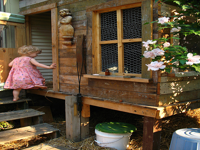

In [42]:
# Example: read the first few lines of the captions file
with open(os.path.join("flickr8k_text", "Flickr8k.token.txt"), "r") as token_file:
    for _ in range(5):
        print(token_file.readline().strip())
# Example: load one image using PIL
from PIL import Image
sample_img = Image.open(os.path.join("images", os.listdir("images")[0]))
display(sample_img.resize((200, 150)))  # display a resized thumbnail of the image


In [40]:
# Verify contents
print("Number of images:", len([f for f in os.listdir("images") if f.endswith('.jpg')]))
print("Number of audio files:", len([f for f in os.listdir("flickr8k_audio/wavs") if f.endswith('.wav')]))
print("Captions file exists:", os.path.exists("flickr8k_text/Flickr8k.token.txt"))

Number of images: 8091
Number of audio files: 40000
Captions file exists: True
